<a href="https://colab.research.google.com/github/Chaitralikore/Remote-Sensing/blob/main/3_Calculate_Vegetation_%26_Water_Soil_Indices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install earthpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.4 MB/s eta 0:00:00


In [2]:
import rasterio as rio
import numpy as np

In [8]:
img_red="/content/sample_data/3/MODIS_NIR.tif"
img_nir="/content/sample_data/3/MODIS_RED.tif"

In [9]:
ds_nir = rio.open(img_nir)
data_nir = ds_nir.read()

ds_red = rio.open(img_red)
data_red = ds_red.read()

data_NDVI = (data_nir - data_red) / (data_nir + data_red)

data_NDVI[np.isnan(data_NDVI)] = -9999

print(data_NDVI)

[[[-1.         -1.         -1.         ... -0.27272727 -0.27722772
   -0.28648649]
  [-1.         -1.         -1.         ... -0.35789474 -0.36
   -0.32947977]
  [-1.         -1.         -1.         ... -0.45       -0.40606061
   -0.36046512]
  ...
  [-0.85542169 -0.85542169 -0.85542169 ... -0.81595092 -0.75581395
   -0.64397906]
  [-0.80116959 -0.79545455 -0.85454545 ... -0.73033708 -0.64948454
   -0.52830189]
  [-0.81818182 -0.80952381 -0.85365854 ... -0.67539267 -0.55760369
   -0.46846847]]]


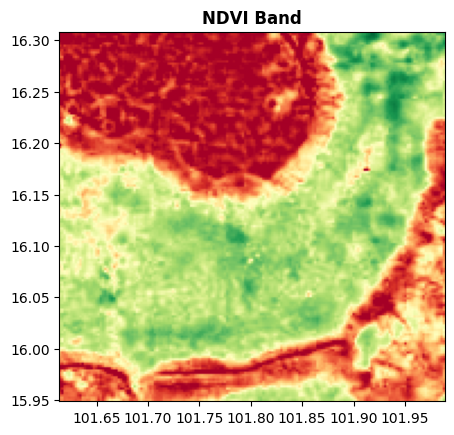

<Axes: title={'center': 'NDVI Band'}>

In [11]:
#Create NDVI raster
with rio.open("/content/sample_data/3/output.tif", 'w',
              driver = 'GTiff',
              width = ds_nir.width,
              height = ds_nir.height,
              count = ds_nir.count,
              crs = ds_nir.crs,
              transform = ds_nir.transform ,
              dtype = 'float64',
              nodata = -9999) as dst:
              dst.write(data_NDVI)

from rasterio.plot import show
ds = rio.open("/content/sample_data/3/output.tif")
show(ds, transform = ds.transform, cmap="RdYlGn", title="NDVI Band")

NDWI For B3 and B5 **bands**

In [13]:
img_b3="/content/sample_data/3/B3.tif"
img_b5="/content/sample_data/3/B5.tif"

ds_b3 = rio.open(img_b3)
data_b3 = ds_b3.read(1).astype('float32')

ds_b5 = rio.open(img_b5)
data_b5 = ds_b5.read()

data_NDWI = (data_b3-data_b5) / (data_b3+data_b5)

data_NDWI[np.isnan(data_NDWI)] = -9999
data_NDWI

array([[[-0.29606587, -0.3139923 , -0.33333334, ..., -0.44729412,
         -0.4072715 , -0.39159548],
        [-0.30297688, -0.33464706, -0.33986792, ..., -0.46642682,
         -0.46911776, -0.46542394],
        [-0.3470041 , -0.34776875, -0.3646956 , ..., -0.4782294 ,
         -0.50892055, -0.5367465 ],
        ...,
        [-0.3261153 , -0.35409486, -0.34167007, ..., -0.31920373,
         -0.3355381 , -0.3125106 ],
        [-0.40636697, -0.3923579 , -0.33470598, ..., -0.33822635,
         -0.3505514 , -0.34127563],
        [-0.32755858, -0.3776957 , -0.32344213, ..., -0.3099741 ,
         -0.31249592, -0.3227325 ]]], dtype=float32)

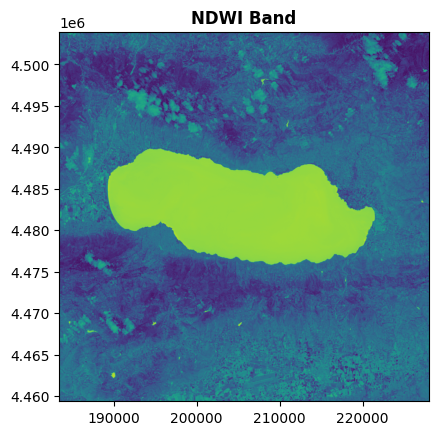

<Axes: title={'center': 'NDWI Band'}>

In [15]:
#Create NDVI raster
with rio.open("/content/sample_data/3/output-b3b5.tif", 'w',
              driver = 'GTiff',
              width = ds_b3.width,
              height = ds_b3.height,
              count = ds_b3.count,
              crs = ds_b3.crs,
              transform = ds_b3.transform ,
              dtype = 'float32',
              nodata = -9999) as dst:
              dst.write(data_NDWI)

from rasterio.plot import show
ds = rio.open("/content/sample_data/3/output-b3b5.tif")
show(ds, transform = ds.transform, cmap="viridis", title="NDWI Band")